# Does the Bullish Percent Index actually "call" tops and bottoms? 📊
### A famous breadth gauge — count how many stocks are bullish — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_turns%3F: Busted](https://img.shields.io/badge/Forecasts_turns%3F-Busted-8b949e?style=flat-square)

Open any market-internals dashboard and you'll find the **Bullish Percent Index** (BPI): the *percentage of a basket that is bullish*. The lore, taught by its inventor Abe Cohen and repeated on every breadth-analysis site, is that the BPI **calls turns** — when it climbs above **70**, too many stocks are already bullish and a *top* is near (sell); when it sinks below **30**, breadth is *washed out* and a *bottom* is near (buy). The reversal up out of oversold is supposed to be a high-probability long.

It *looks* compelling on a hand-picked chart. But a buy-the-dip rule on a market that drifts **up** will look profitable no matter what. So we did the only fair thing: encode the BPI **mechanically** (% of the basket above its 50-day average — no eyeballing), fire the "buy the oversold cross" rule across 21 years of SPY, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bullish_percent_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def breadth_and_spy():
    panel = data.breadth_basket(allow_fetch=False)
    panel = panel[panel.index <= ASOF]
    bser = st.bpi(panel, ma_win=st.DEFAULT_MA)
    spy = data.load_real("SPY", allow_fetch=False)
    spy = spy[(spy.index <= ASOF) & (spy.index.isin(bser.index))]
    bser = bser[bser.index.isin(spy.index)]
    return spy["close"], bser
print("real BPI cache present:", HAVE_REAL, "| breadth members:", data.BREADTH_MEMBERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'members': ['SPY', 'QQQ', 'IWM', 'DIA'], 'traded': 'SPY', 'n_entries': 159, 'ma': 50, 'oversold': 30, 'fp_spy': '4cb5244f3990', 'bpi_mean': 68.2, 'bpi_pct_lo': 27.6, 'bpi_pct_hi': 66.7, 'h5': (5, 159, -8.6, 57, -0.41, 18.6, -27.2, -10.6, -1.0, 0.318), 'h10': (10, 159, 37.0, 66, 1.07, 33.8, 3.2, 35.0, 0.08, 0.933), 'h20': (20, 159, 37.0, 67, 0.53, 82.6, -45.5, 35.0, -0.83, 0.406), 'h60': (60, 158, 207.5, 72, 1.72, 209.1, -1.6, 205.5, -0.02, 0.984), 'per': [('SPY', 159, 37.0, 0.53, 82.6, -45.5), ('QQQ', 159, 71.9, 0.98, 138.6, -66.7), ('IWM', 159, 49.9, 0.6, 64.1, -14.2), ('DIA', 159, 38.8, 0.6, 70.0, -31.2), ('GLD', 159, 63.3, 1.53, 88.4, -25.1)], 'placebo': (37.0, 0.974, 500), 'syn': [(0.0, 141, 4.2, 53, 0.08), (0.6, 141, 472.7, 65, 3.38)]}


real BPI cache present: True | breadth members: ['SPY', 'QQQ', 'IWM', 'DIA']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the BPI crosses up out of **oversold (<30)**, do I make money? | **Barely — and not from breadth.** The raw returns are small and the win-rate (~67% at 20d) is just the market grinding up. |
| Is that *the BPI's* doing? | **No.** Buy on **random days** instead and you do **just as well or better**. The BPI adds nothing — at 5 and 20 days the oversold cross is actually *worse* than a coin-flip entry. |
| Does the BPI "call" bottoms? | **Not in any usable way.** Re-time the breadth series at random and the result barely changes. The timing isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a breadth signal. |

> The BPI is a fine way to *describe* how broad a rally is. As a *forecast* — "oversold breadth will bounce" — it's a **mirage**: the small apparent edge is the market's long-run climb, none of it is the breadth.

## 1 · The claim

> *"Count the percentage of stocks on a Point & Figure **buy** signal. Above 70 the market is overbought (sell); below 30 it is oversold (buy). When the index reverses up out of oversold, breadth has washed out — buy the bottom."*

This is **Abe Cohen's** Bullish Percent Index (Chartcraft, 1955), still taught today and tracked on StockCharts, Investors Intelligence and every market-internals service. It's one of the most recognisable breadth tools in technical analysis — so: does the thermometer actually *forecast*?

## 2 · So what?

If the BPI genuinely *forecast* reversals, it would be remarkable: a count of how many stocks are bullish *today* would predict the index's turn *tomorrow*, a clean crack in market efficiency you could trade. That's the dream the tool sells.

But there's a trap built into it. "Oversold breadth → buy" is just **buy-the-dip**, fired on a market (stock indices) that drifts **up** over time — so *any* dip-buying rule will look profitable. To separate the **tool** from the **tide**, we have to (a) compute the BPI by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take a small **breadth basket** (SPY, QQQ, IWM, DIA), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the BPI mechanically.** Each member casts a vote: is it **above its 50-day average**? The BPI is the % of yes-votes (0-100). This is a transparent proxy for the classic 'on a P&F buy signal' count, and it uses only past data — no look-ahead.
2. **Trade the lore.** When the BPI **crosses up through 30** (a reversal out of oversold), buy SPY at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the BPI matters, the oversold cross must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the mechanical BPI even look like? Here's the breadth oscillator under SPY, with the 30/70 bands and the oversold-cross buys the rule would take.

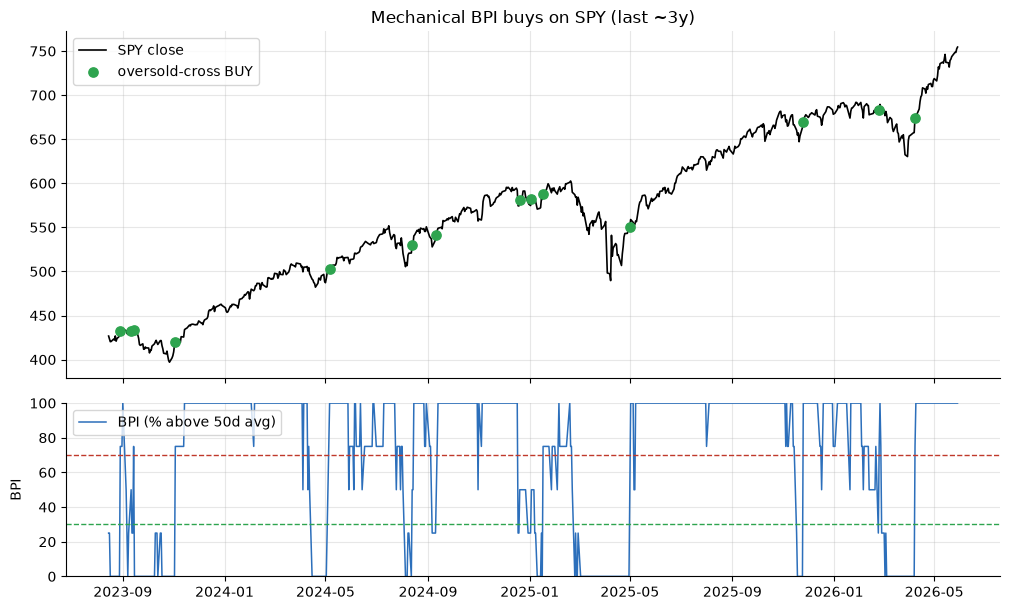

oversold crosses in window: 14


In [2]:
if HAVE_REAL:
    cl, b = breadth_and_spy()
    seg = slice(-700, None)
    ent = st.oversold_cross_entries(b, R['oversold'])
    ent = ent[ent >= cl.index[seg][0]]
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.2), sharex=True,
                                 gridspec_kw={'height_ratios':[2,1]})
    a1.plot(cl.index[seg], cl.values[seg], c='k', lw=1.2, label='SPY close')
    a1.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='oversold-cross BUY')
    a1.set_title('Mechanical BPI buys on SPY (last ~3y)'); a1.legend(loc='upper left')
    a2.plot(b.index[seg], b.values[seg], c='#2c6fbb', lw=1.1, label='BPI (% above 50d avg)')
    a2.axhline(70, c=RED, ls='--', lw=1); a2.axhline(30, c=GREEN, ls='--', lw=1)
    a2.set_ylim(0,100); a2.set_ylabel('BPI'); a2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('oversold crosses in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The BPI tracks how broad the rally is — *as a description*. The question is whether those green buy dots are followed by bounces. **Let's race the oversold cross against random entries** at four horizons. Blue = buy the oversold cross; grey = buy on random days.

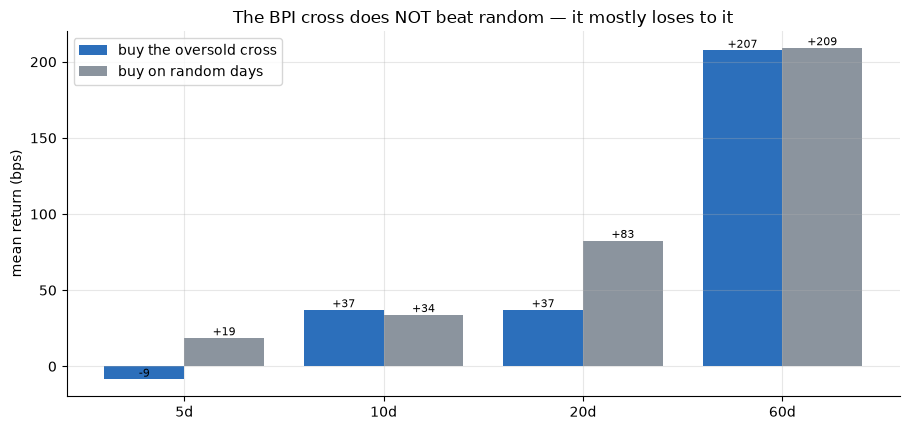

cross: [-9, 37, 37, 207]
random: [19, 34, 83, 209]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cl, b = breadth_and_spy()
    e = st.oversold_cross_entries(b, R['oversold'])
    re = st.random_entries(cl, max(len(e),50), seed=7)
    cross = [st.forward_returns(cl,e,h).mean()*1e4 for h in hs]
    rnd = [st.forward_returns(cl,re,h).mean()*1e4 for h in hs]
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='buy the oversold cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The BPI cross does NOT beat random — it mostly loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The oversold cross makes a little money in absolute terms (**+37 bps** over 20 days) — but **random entries make more** (**+83 bps**). At 5 and 20 days the famous BPI is *worse* than throwing darts; at 10 and 60 it's a dead heat. The apparent edge was **the market's upward drift**, not the breadth (the quants notebook shows the *t* never clears 2).

**One more sanity check.** What if we scramble the BPI's *timing* — keep the same breadth values but shuffle when they occur, so the oversold crosses fire on dates unrelated to the real breadth path? If breadth really 'calls bottoms', the scrambled version should do much worse.

In [4]:
if HAVE_REAL:
    cl, b = breadth_and_spy()
    pl = st.scrambled_breadth_placebo(cl, b, 20, oversold=R['oversold'], n_draws=300, seed=494)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real BPI oversold cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *time-scrambled* breadth series do at least as well (p={pval:.2f}).')
print('=> the breadth timing is not doing the work.')

real BPI oversold cross (SPY, 20d): +37.0 bps
... but 98% of *time-scrambled* breadth series do at least as well (p=0.98).
=> the breadth timing is not doing the work.


Almost all of the **scrambled** breadth series match or beat the real one (*p* = 0.97). If price genuinely turned on *this specific breadth path*, a random re-timing would collapse the result. It doesn't — because the result was never about the breadth.

## 5 · The verdict

- **Signal — None.** The oversold-cross buy does **not** beat buying on random days (it's *worse* at 5 and 20 days; the cross-vs-random difference never clears *t* = 2). The returns are the market's drift, not the breadth.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the BPI forecast turns"? — Busted.** Re-time the breadth at random and the result barely moves. The thermometer doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The oversold cross's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The BPI buy is a worse, more expensive way to be long. Costs (commissions + spread on every cross) push the already-no-edge result further negative. As a forecasting tool, it doesn't pay; as a breadth gauge, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The overbought leg.** We tested the oversold *buy*; the symmetric "BPI > 70 → sell" top-call inherits the same drift problem in reverse (shorting a rising market) and fares no better.
- **A truer BPI.** Real BPI counts full-exchange P&F buy signals; our % -above-MA proxy is coarse and *caps* the test. But the drift confound — the reason the edge appears — is structural and would survive a finer proxy.
- **A real positive control.** The quants notebook plants a *genuine* oversold-bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the BPI forecasts turns? Show the oversold cross beating random entries at **t ≥ 2** on a real tape — then we'll talk.*